# 23 - Oversampling by Exact Replication

**Section:** More on Data | **Prereqs:** `More on Data/FeatureAugmentation.ipynb` | **Next:** `More on Data/Handeling_Unbalanced_Data_noise_augmentation.ipynb`

The simplest response to too little data or an under-represented class: copy the
samples. Here the training set is literally concatenated with itself.

**What copying does and does not do**
- It does not add information. A duplicated sample carries the same gradient
  signal twice.
- It does change *how often* the optimizer sees that sample per epoch - which is
  exactly the point when one class is rare.
- It roughly doubles epoch time for no new information, so at a fixed compute
  budget it can be worse than doing nothing.

**The leak this notebook warns about, in the conclusion at the bottom:** duplicate
*after* splitting, never before. Duplicate first and copies of the same sample
land in both train and test, so the test set is measuring memorisation. This is
the most common data-leakage bug in practice.

**The alternatives**, in increasing order of usefulness: class weights in the
loss (`CrossEntropyLoss(weight=...)`), a `WeightedRandomSampler` in the
DataLoader, and augmentation with variation - the next notebook.

# 1) Over Sampling by exact replication

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset,DataLoader

from torchvision.transforms import ToTensor
from torchvision.datasets import MNIST

In [ ]:
# MNIST as usual.
train_data = MNIST(
    root='./data',        # Directory to store the dataset
    train=True,           # Load the training set
    download=True,
    transform = ToTensor()
)

test_data =  MNIST(
    root='./data',        # Directory to store the dataset
    train=False,           # Load the training set
    download=True,
    transform = ToTensor()
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.83MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.42MB/s]


In [ ]:
# Builds a small training set of n samples, optionally DOUBLED by
# concatenating it with itself. That flag is the entire experiment.
# Note the copies are exact: torch.cat((x,x)) adds no variation whatsoever.
# .clone().detach() is the correct way to copy a tensor (torch.tensor(t) warns).
def makeDataset(n,boolDouble):

  data_tensor = train_data.data.view(-1, 784)
  labels_tensor = train_data.targets

  data_subset = data_tensor[:n].clone().detach() # Use clone().detach()
  labels_subset = labels_tensor[:n].clone().detach() # Use clone().detach()

  if boolDouble:
    data_subset = torch.cat( (data_subset,data_subset), axis=0 )
    labels_subset = torch.cat( (labels_subset,labels_subset), axis= 0)

  # Prepare test data tensors
  test_data_tensor = test_data.data.view(-1, 784).clone().detach().float().to('cuda') # Use clone().detach() and move to cuda
  test_labels_tensor = test_data.targets.clone().detach().long().to('cuda') # Use clone().detach() and move to cuda


  train_tensor = TensorDataset(data_subset.float().to('cuda'), labels_subset.long().to('cuda'))
  test_tensor = TensorDataset(test_data_tensor,test_labels_tensor)

  bs = 32
  data_loader = DataLoader(train_tensor, batch_size=bs, drop_last=True, shuffle=True)
  test_loader = DataLoader(test_tensor, batch_size=test_data_tensor.shape[0])


  return data_loader, test_loader

In [ ]:
# The usual 784-128-64-32-10 classifier, log_softmax out.
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(784, 128)

    self.fc1 = nn.Linear(128,64)

    self.fc2 = nn.Linear(64,32)

    self.output_layer = nn.Linear(32,10)


  def forward(self,x):

    x = F.relu(self.input_layer(x))

    x = F.relu(self.fc1(x))

    x = F.relu(self.fc2(x))

    return torch.log_softmax(self.output_layer(x), dim=1)

In [ ]:
# Training function taking (n, boolDouble) so the two conditions can be run
# back to back with everything else held constant.
def train_model(n,boolDouble):

  data_loader, test_loader = makeDataset(n, boolDouble)

  classifier = model().to('cuda')

  epochs = 50
  lr = 0.0001

  lossFunc = nn.NLLLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=lr)

  test_acc = []
  train_acc = []
  losses = torch.zeros(epochs)


  for i in range(epochs):

    classifier.train()
    batch_acc = []
    batch_loss = []

    for x,y in data_loader:

      yhat = classifier(x)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())


      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100 * torch.mean( (torch.argmax(yhat,dim = 1) == y).float()).cpu() )

    train_acc.append(np.mean(batch_acc))
    losses[i] = np.mean(batch_loss)

    if i % 10 == 0 or i == epochs-1:
      print(f"Sample Size = {data_loader.dataset.tensors[0].shape[0]} |Epoch {i} : Loss = {losses[i].item()}")

    classifier.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      Preds = torch.argmax(classifier(X), dim = 1)
      test_acc.append( 100 * torch.mean( (Preds == Y).float()) )

  print()
  return losses, train_acc, test_acc, classifier


In [ ]:
# The comparison: 200 samples vs the same 200 duplicated to 400.
# The doubled run sees twice as many gradient updates per epoch, so its loss
# falls faster per epoch - which is not the same as learning more.
losses, train_acc, test_acc, classifier = train_model(200,False)
lossesTrue, train_accTrue, test_accTrue, classifierTrue = train_model(200, True)

Sample Size = 200 |Epoch 0 : Loss = 3.8890581130981445
Sample Size = 200 |Epoch 10 : Loss = 0.4608306884765625
Sample Size = 200 |Epoch 20 : Loss = 0.09794366359710693
Sample Size = 200 |Epoch 30 : Loss = 0.03664025664329529
Sample Size = 200 |Epoch 40 : Loss = 0.019145334139466286
Sample Size = 200 |Epoch 49 : Loss = 0.012928486801683903

Sample Size = 400 |Epoch 0 : Loss = 4.121513366699219
Sample Size = 400 |Epoch 10 : Loss = 0.17248637974262238
Sample Size = 400 |Epoch 20 : Loss = 0.03700970858335495
Sample Size = 400 |Epoch 30 : Loss = 0.014780922792851925
Sample Size = 400 |Epoch 40 : Loss = 0.007694430649280548
Sample Size = 400 |Epoch 49 : Loss = 0.004753881134092808



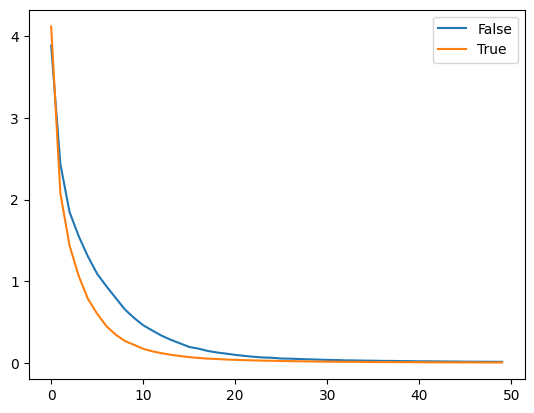

In [ ]:
# Loss curves. The doubled run looks better; the next two plots ask whether
# that is real.
plt.plot(losses, label = "False")
plt.plot(lossesTrue, label = "True")
plt.legend();

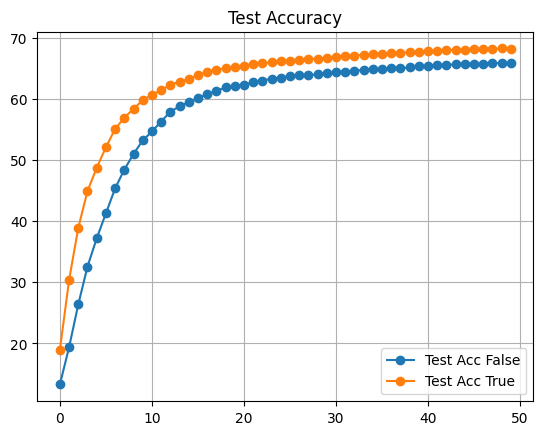

In [ ]:
# TEST accuracy - the honest comparison. Expect little or no gain: duplicates
# carry no new information about unseen digits.
test_acc = [i.cpu() for i in test_acc]
test_accTrue = [i.cpu() for i in test_accTrue]

plt.plot(test_acc,'o-',label="Test Acc False")
plt.plot(test_accTrue,'-o',label="Test Acc True")

plt.title("Test Accuracy")
plt.grid()
plt.legend();

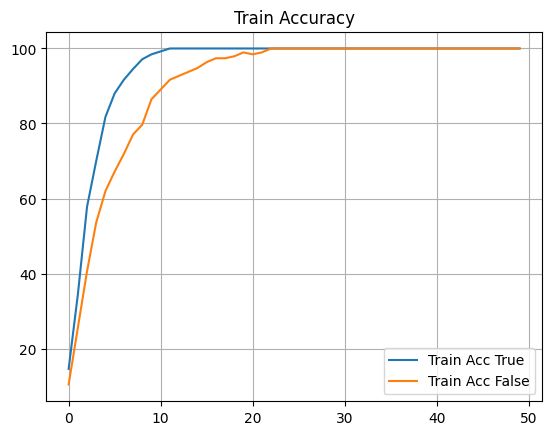

In [ ]:
# TRAIN accuracy, where the doubled run does look better - because it is now
# being scored on data it has seen twice as often. This gap between the two
# plots is the lesson.
plt.plot(train_accTrue, label="Train Acc True")
plt.plot(train_acc, label="Train Acc False")
plt.grid()
plt.title("Train Accuracy")
plt.legend();

### **Conclusion**

If we double the dataset, we must split it into train, dev, and test sets before doubling.
Doubling first can lead to data leakage, because identical or very similar samples could end up in both training and evaluation sets, making performance metrics unreliable.

Correct process:

1. Split the original dataset into train, dev, and test.
2.  Augment only the training set to increase data size without contaminating evaluation sets.




